# Bayesian Optimization Strategies for Black-Box Functions

This project explores various Bayesian Optimization (BO) strategies to efficiently optimize several black-box functions. The goal is to find optimal input parameters that maximize the output of these functions, typically within a constrained search space. The notebook tracks weekly submissions, incorporating new evaluation results and adapting the BO approach over time.

## Submissions History

The following is a chronological record of the Bayesian Optimization strategies employed and key observations from weekly evaluations:

*   **Week 1**: Initial exploration using random search with exploitation.
*   **Week 2-3**: Gaussian Process (GP) with `GPyOpt.methods.BayesianOptimization`. Noted issues with incorrect bounds leading to `1.000000` as a suggested input for some functions.
*   **Week 4-5**: Switched to Gpytorch BO, utilizing Beta 2.0 and Upper Confidence Bound (UCB) as the acquisition function.
*   **Week 6-7**: Continued with Gpytorch BO, but incorporated dynamic updates for hyperparameters like Beta and introduced the option for Expected Improvement (EI) alongside UCB.
*   **Week 8-9**: Explored Neural Networks as surrogate models, implemented with BoTorch.
*   **Week 10-11**: Adopted Logistic Regression as the surrogate model, treating the optimization as a binary classification problem.
*   **Week 12**: A hybrid approach was taken:
    *   **Functions 1-6**: PyTorch BO with Beta 2.0 and UCB, as this strategy had consistently yielded the highest performance.
    *   **Function 7**: Neural Networks with BoTorch.
    *   **Function 8**: Gpytorch BO with dynamically updated hyperparameters for Beta and UCB/EI.
*   **Week 13**: A hybrid approach was taken depending on the max value:
    *   **Functions 1-6**: PyTorch BO with Beta 2.0 and UCB, as this strategy had consistently yielded the highest performance.
    *   **Function 7**: Neural Networks with BoTorch.
    *   **Function 8**: Gpytorch BO with dynamically updated hyperparameters for Beta and UCB/EI.

## Bayesian Optimization with Gaussian Process (GP) Surrogate

This section implements Bayesian Optimization using a Gaussian Process as the surrogate model. The core idea is to model the unknown black-box function probabilistically, which provides both a mean prediction and an uncertainty estimate for any input. This allows for intelligent exploration of the search space.

### Key Components:

*   **Data Aggregation**: Combines historical data with the latest weekly black-box results.
*   **Dynamic Dimensionality**: Automatically determines the input dimensionality and sets search bounds (0.0 to 0.999999).
*   **GP Model (`SingleTaskGP`)**: Fits a Gaussian Process model to the observed data, capturing the underlying function's behavior and uncertainty.
*   **Hyperparameter Optimization (`fit_gpytorch_mll`)**: Optimizes the GP's internal hyperparameters by maximizing the marginal log-likelihood.
*   **Adaptive Hyperparameter Heuristics**: Dynamically adjusts the `beta_value` for the UCB acquisition function. If observed outputs are consistently low or the data's standard deviation is small (suggesting convergence), `beta_value` is increased to encourage more exploration.
*   **Acquisition Function**: Uses either `LogExpectedImprovement` (EI) or `UpperConfidenceBound` (UCB) to guide the search for the next optimal input.
*   **Acquisition Function Optimization (`optimize_acqf`)**: Finds the input that maximizes the chosen acquisition function.
*   **Duplicate Handling**: Checks for and avoids suggesting input points that are too close to already evaluated ones. A small perturbation is applied as a fallback if a unique point cannot be found after multiple retries.

## Bayesian Optimization with Neural Network (NN) Surrogate

This approach utilizes a custom feed-forward Neural Network as the surrogate model for Bayesian Optimization, moving away from probabilistic models like GPs. The NN learns a direct mapping from input parameters to function outputs.

### Key Components:

*   **`NeuralNetworkSurrogate` Class**: Defines a simple multi-layer perceptron (MLP) with ReLU activations for two hidden layers and a single output neuron.
*   **`train_nn_surrogate` Function**: Handles the training of the NN using Adam optimizer and Mean Squared Error (MSE) loss for a specified number of epochs (100 in this implementation).
*   **Data Aggregation and Preparation**: Similar to the GP approach, historical and new data are combined and converted into PyTorch tensors.
*   **Acquisition Strategy**: Since standard NNs do not inherently provide uncertainty estimates, the acquisition strategy is different:
    1.  A set of `num_candidates` (e.g., 200) random input points are generated within the bounds.
    2.  The trained `NeuralNetworkSurrogate` predicts the output for each candidate.
    3.  The candidate with the highest predicted output is selected as the next suggested input.
*   **Duplicate Handling**: Similar to the GP method, this approach also incorporates checks for duplicate points and applies perturbations if a unique input cannot be found, ensuring diversity in the suggested evaluations.

## Bayesian Optimization with Logistic Regression (LR) Surrogate

This section introduces a unique Bayesian Optimization strategy that leverages Logistic Regression as the surrogate model. The core innovation here is the transformation of the continuous optimization problem into a binary classification task.

### Key Components:

*   **Data Aggregation and Preparation**: As with other methods, historical and new data are combined. Inputs are used as features for the LR model.
*   **Output Binarization**: This is the crucial step. The continuous black-box function outputs (`Y_np`) are converted into binary labels (`y_binary`). A common heuristic is applied: outputs greater than the median of all observed outputs are labeled as `1` ('good' outcome), and others as `0` ('bad' outcome). This reframes the maximization problem into finding inputs likely to yield a 'good' classification.
*   **Logistic Regression Model (`sklearn.linear_model.LogisticRegression`)**: An LR model is trained on the historical inputs (`X_np`) and their binarized outputs (`y_binary`). `solver='liblinear'` and `C=0.1` are used for robust training with a small amount of regularization.
*   **Acquisition Strategy**: The goal is to maximize the probability of obtaining a 'good' outcome:
    1.  `num_candidates` random input points are generated within the search bounds.
    2.  The trained `LogisticRegression` model predicts the probability of each candidate belonging to class `1` (`lr_model.predict_proba`).
    3.  The candidate input with the highest predicted probability of being in class `1` is selected as the next suggested input.
*   **Duplicate Handling**: Similar mechanisms for checking and perturbing duplicate points are employed to ensure that diverse input suggestions are provided, even in cases where the acquisition function repeatedly points to already explored regions.

In [2]:
import numpy as np

from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/My Drive/Colab Notebooks/

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content/drive/My Drive/Colab Notebooks


In [3]:
!pip install torch botorch gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 14.0 MB/s eta 0:00:00


### Incorporating This Week's Blackbox Evaluation Results

Based on the input and output values provided in the previous text cell, I've created a dictionary `weekly_data_to_add` that contains the new results for each function. This dictionary will be used within the Bayesian Optimization loop to append this week's data to the historical `initial_inputs` and `initial_outputs` for each respective function before training the model.


--- Visualizing Current Week's New Output Data ---


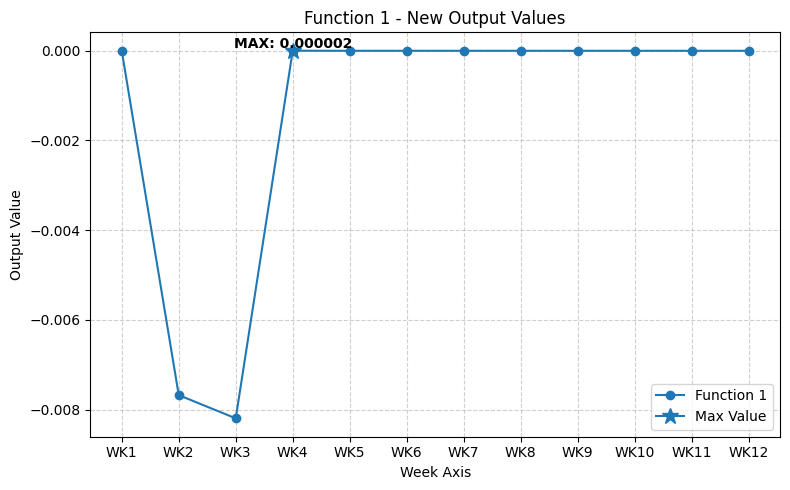

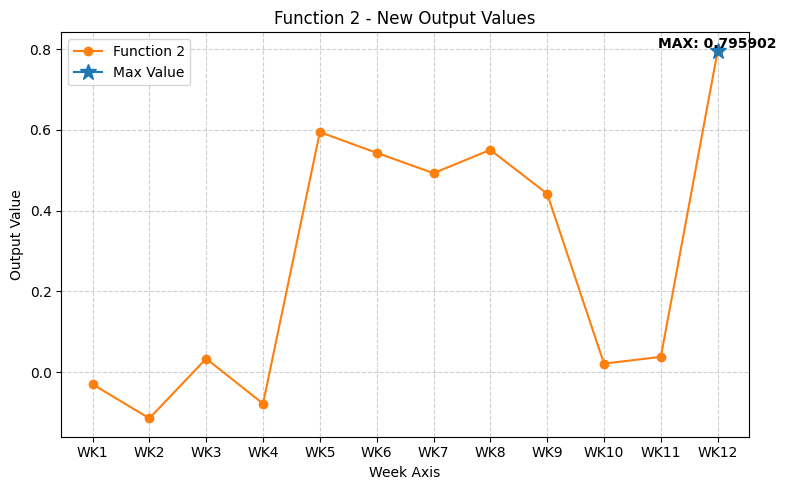

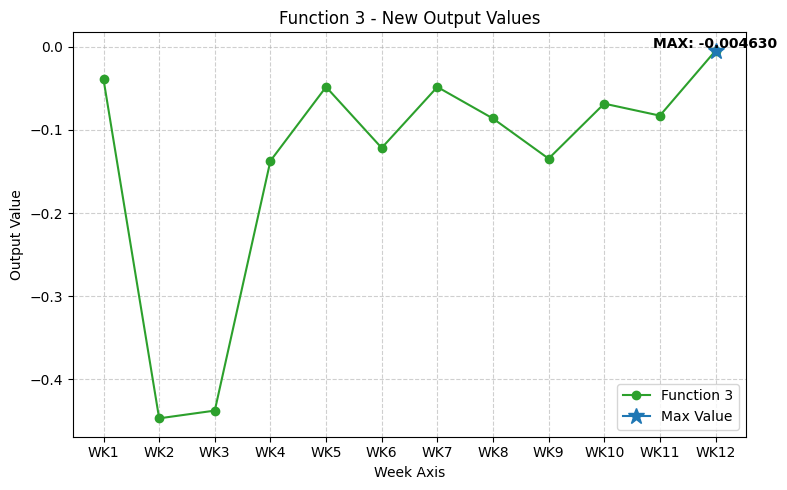

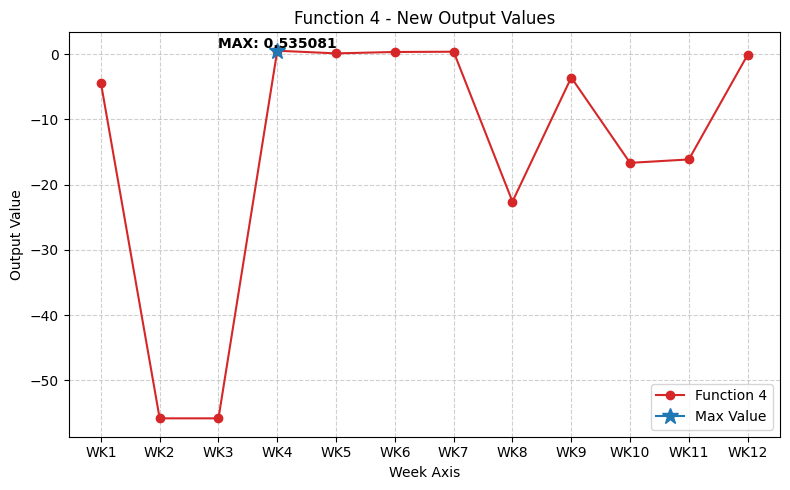

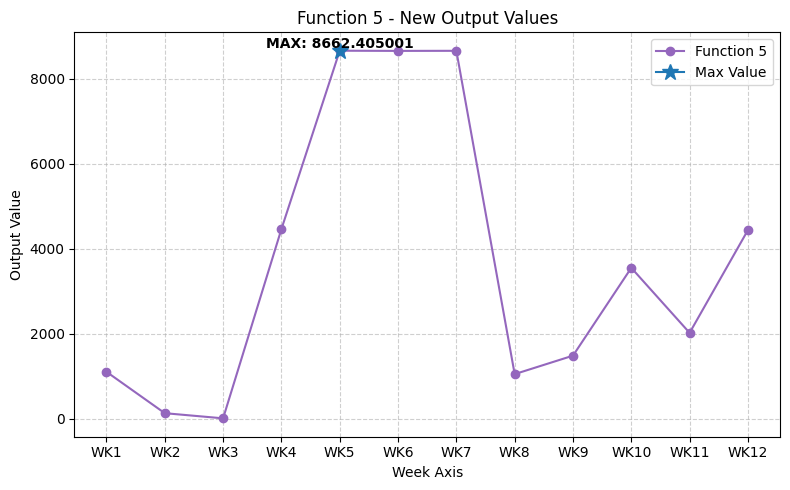

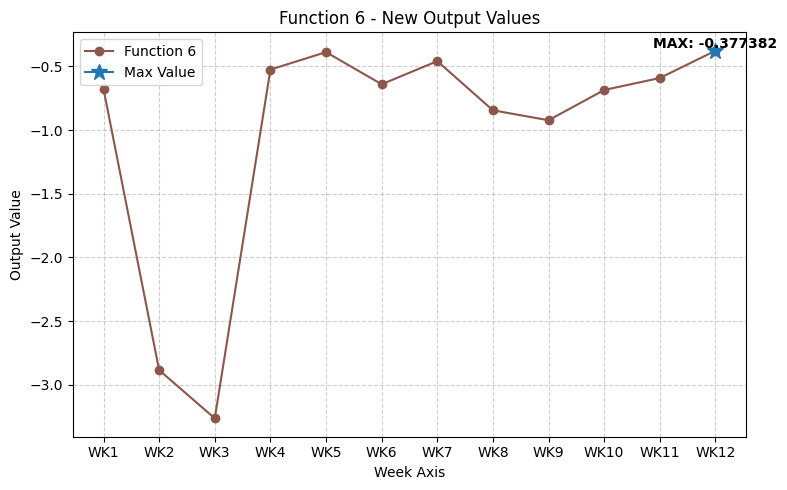

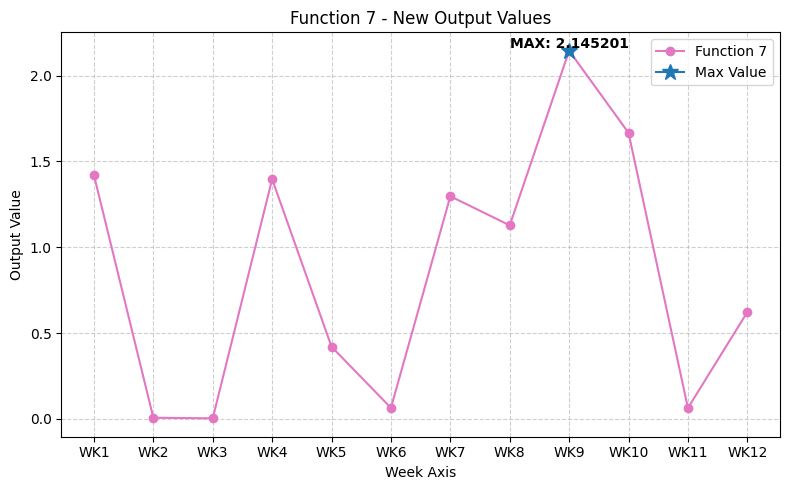

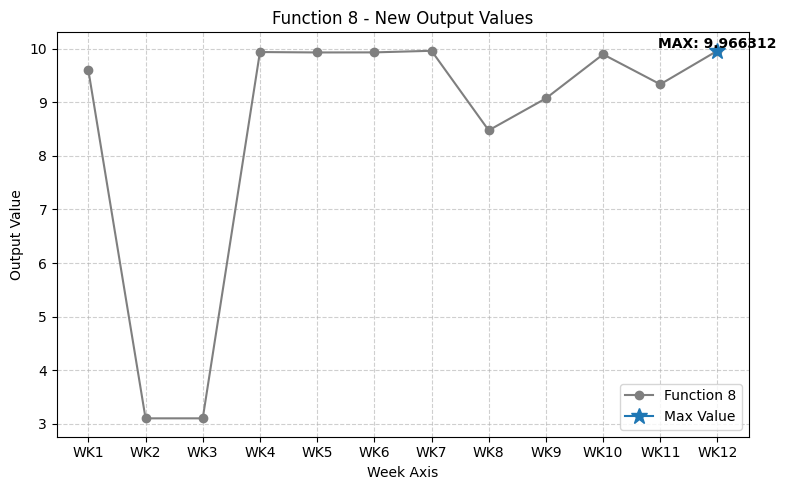

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Dictionary containing this week's new blackbox inputs and outputs for each function.
# These values are parsed from the 'This week's input values' and 'This week's output values' in the notebook.
weekly_data_to_add = {
    1: {
        'inputs': np.array([
            [0.800000, 0.732999],
            [0.645303, 0.678430],
            [0.645577, 0.676983],
            [0.364590, 0.353163],
            [0.532789, 0.817266],
            [0.034133, 0.980602],
            [0.702175, 0.810049],
            [0.266471, 0.547321],
            [0.293338, 0.483293],
            [0.100778, 0.018222],
            [0.020584, 0.969909],
            [0.497602, 0.999999]
        ]),
        'outputs': np.array([
            -8.338151836816169e-29,
            -0.007678957419520911,
            -0.00819713557792069,
            0.000001927434295967798,
            -3.5146397031494507e-32,
            2.9e-322,
            -2.3970919683111303e-27,
            6.30224921509662e-29,
            -2.7203820395152957e-15,
            -3.1620958307066555e-185,
            1.966e-321,
            -1.0662271732842112e-108
        ])
    },
    2: {
        'inputs': np.array([
            [0.800000, 0.926564],
            [0.152163, 0.338723],
            [0.180641, 0.344489],
            [0.958278, 0.000000],
            [0.699730, 0.000000],
            [0.685294, 0.999999],
            [0.719853, 0.674874],
            [0.702198, 0.013774],
            [0.659209, 0.016779],
            [0.974394, 0.986210],
            [0.973488, 0.968877],
            [0.691759, 0.378587]
        ]),
        'outputs': np.array([
            -0.029503462535341373,
            -0.11396233459497623,
            0.03382494832876154,
            -0.07771355578156476,
            0.594498239556574,
            0.5431938328721126,
            0.4928748247572653,
            0.5504310874712948,
            0.4418045501760841,
            0.021458440151366776,
            0.03825864197118936,
            0.7959021469248222
        ])
    },
    3: {
        'inputs': np.array([
            [0.550000, 0.611593, 0.340176],
            [0.150606, 0.514961, 1.000000],
            [0.104805, 0.609437, 0.999999],
            [0.999999, 0.000000, 0.794233],
            [0.696026, 0.107542, 0.463492],
            [0.194836, 0.348703, 0.000000],
            [0.427334, 0.999999, 0.504266],
            [0.152138, 0.049156, 0.457428],
            [0.918941, 0.946718, 0.182141],
            [0.130086, 0.758262, 0.024587],
            [0.371038, 0.987649, 0.040109],
            [0.539682, 0.549364, 0.478114]
        ]),
        'outputs': np.array([
            -0.0390175611057545,
            -0.447023284691769,
            -0.4377140674325277,
            -0.13718171225203948,
            -0.048220362291616026,
            -0.12161391926895466,
            -0.048267671642103854,
            -0.08619739440926846,
            -0.13450388606860958,
            -0.06832284449662505,
            -0.08276356502376149,
            -0.00462997320791903
        ])
    },
    4: {
        'inputs': np.array([
            [0.600000, 0.428771, 0.425825, 0.249007],
            [1.000000, 1.000000, 1.000000, 1.000000],
            [0.999999, 0.999999, 0.999999, 0.999999],
            [0.402563, 0.400307, 0.357525, 0.407750],
            [0.398081, 0.398554, 0.332050, 0.418960],
            [0.397172, 0.396162, 0.340361, 0.419077],
            [0.389866, 0.391067, 0.369265, 0.421938],
            [0.106274, 0.009954, 0.015450, 0.032715],
            [0.176699, 0.442108, 0.386074, 0.425967],
            [0.065366, 0.487571, 0.033614, 0.062653],
            [0.220853, 0.038930, 0.036019, 0.175222],
            [0.410885, 0.396781, 0.322602, 0.420239]
        ]),
        'outputs': np.array([
            -4.366506673946599,
            -55.82793509489924,
            -55.827686352381896,
            0.5350812949774135,
            0.1269397678248585,
            0.3417991419959958,
            0.37906411360370074,
            -22.60108668368336,
            -3.5722246369839286,
            -16.65823443412395,
            -16.133705355027647,
            -0.09272449173248942
        ])
    },
    5: {
        'inputs': np.array([
            [0.320000, 0.846480, 0.879484, 0.878515],
            [0.614148, 0.000000, 0.933712, 0.115606],
            [0.545712, 0.802363, 0.231289, 0.514652],
            [0.271611, 0.999999, 0.999999, 0.999999],
            [0.999999, 0.999999, 0.999999, 0.999999],
            [0.999961, 0.999909, 0.999999, 0.999905],
            [0.999999, 0.999999, 0.999956, 0.999924],
            [0.782352, 0.645903, 0.768917, 0.940522],
            [0.714213, 0.813548, 0.989741, 0.712325],
            [0.792594, 0.907898, 0.943701, 0.960135],
            [0.296357, 0.938315, 0.818739, 0.983566],
            [0.999999, 0.999999, 0.000000, 0.999999]
        ]),
        'outputs': np.array([
            1104.6301400565198,
            130.78876638959116,
            9.425659890813808,
            4463.350590860773,
            8662.405001248297,
            8658.104897778145,
            8660.119161692883,
            1050.1226677565057,
            1484.7193887847236,
            3551.858299646431,
            2021.5795329284542,
            4440.480873479282
        ])
    },
    6: {
        'inputs': np.array([
            [0.770000, 0.154692, 0.732551, 0.693996, 0.056401],
            [0.175426, 0.938041, 0.000000, 0.156664, 0.904988],
            [0.064810, 0.999999, 0.000000, 0.028130, 0.999999],
            [0.367117, 0.233084, 0.593107, 0.999999, 0.000000],
            [0.459409, 0.327484, 0.757640, 0.746925, 0.000000],
            [0.481402, 0.272805, 0.999999, 0.855860, 0.000000],
            [0.386130, 0.285285, 0.499511, 0.677552, 0.000000],
            [0.230871, 0.025121, 0.550494, 0.987505, 0.028794],
            [0.542102, 0.147860, 0.302406, 0.936499, 0.046015],
            [0.214696, 0.067234, 0.594847, 0.738866, 0.032443],
            [0.119953, 0.312064, 0.802395, 0.861417, 0.137300],
            [0.306547, 0.451429, 0.543010, 0.807710, 0.055635]
        ]),
        'outputs': np.array([
            -0.6771955885915112,
            -2.883615988040884,
            -3.2621988102886172,
            -0.5254625252422866,
            -0.38831769285035644,
            -0.6406215633745495,
            -0.45926591015760876,
            -0.8449348317069371,
            -0.9230103460230084,
            -0.6855695626125368,
            -0.5916854963498961,
            -0.3773821793376717
        ])
    },
    7: {
        'inputs': np.array([
            [0.100000, 0.491672, 0.247422, 0.218118, 0.420428, 0.730969],
            [0.288811, 0.510675, 0.064570, 0.465677, 1.000000, 0.672952],
            [0.640706, 0.592377, 0.058594, 0.217820, 0.920125, 0.623117],
            [0.000000, 0.334657, 0.401259, 0.098840, 0.367675, 0.833408],
            [0.000000, 0.663264, 0.000000, 0.070083, 0.374752, 0.772576],
            [0.000000, 0.999999, 0.326281, 0.145544, 0.398996, 0.999999],
            [0.000000, 0.379723, 0.000000, 0.318923, 0.381578, 0.806730],
            [0.180476, 0.333308, 0.090879, 0.183768, 0.143884, 0.817537],
            [0.002201, 0.328600, 0.230557, 0.313735, 0.254546, 0.688306],
            [0.060227, 0.297650, 0.298066, 0.320401, 0.164287, 0.783161],
            [0.265047, 0.672059, 0.052024, 0.113646, 0.003918, 0.999460],
            [0.136719, 0.069487, 0.478975, 0.125899, 0.108229, 0.987965]
        ]),
        'outputs': np.array([
            1.4201487472754821,
            0.006596987082662026,
            0.003050285380427639,
            1.3967316947878468,
            0.4202407038284502,
            0.06409827088716658,
            1.297127244569453,
            1.1275328869628096,
            2.14520092965998,
            1.666604251736712,
            0.06326544847865487,
            0.6221243441004702
        ])
    },
    8: {
        'inputs': np.array([
            [0.100000, 0.065955, 0.022928, 0.038786, 0.403935, 0.801055, 0.488307, 0.893084],
            [1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 0.000000, 1.000000, 1.000000],
            [0.999999, 0.999999, 0.999999, 0.999999, 0.999999, 0.000000, 0.999999, 0.999999],
            [0.134613, 0.130598, 0.146610, 0.083118, 0.999999, 0.398970, 0.153874, 0.999999],
            [0.137258, 0.139281, 0.155874, 0.182828, 0.988383, 0.541042, 0.248615, 0.000000],
            [0.140861, 0.205991, 0.100534, 0.303262, 0.919816, 0.500240, 0.267704, 0.999999],
            [0.146159, 0.187154, 0.181287, 0.122938, 0.720399, 0.461661, 0.211008, 0.999999],
            [0.000547, 0.748773, 0.153770, 0.953420, 0.234834, 0.958394, 0.449934, 0.716364],
            [0.029368, 0.057832, 0.147832, 0.274588, 0.082021, 0.012809, 0.632778, 0.157775],
            [0.050323, 0.062907, 0.187347, 0.032471, 0.743352, 0.723330, 0.136056, 0.836078],
            [0.261671, 0.066991, 0.028191, 0.244745, 0.881485, 0.415913, 0.720333, 0.918284],
            [0.106095, 0.134824, 0.192497, 0.168886, 0.861283, 0.511635, 0.240597, 0.999999]
        ]),
        'outputs': np.array([
            9.6022751138859,
            3.098299999999999,
            3.098315699990401,
            9.9414645679814,
            9.9338673571405,
            9.9350862114049,
            9.9648545421214,
            8.4783909311774,
            9.07579930818,
            9.8985683602926,
            9.3387487905439,
            9.9663117558634
        ])
    }
}



# Color list to ensure different colors for each function's plot
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

print("\n--- Visualizing Current Week's New Output Data ---")
for function_idx, data in weekly_data_to_add.items():
    new_outputs = data['outputs']
    num_points = len(new_outputs)
    x_indices = np.arange(num_points) + 1
    week_labels = [f"WK{i}" for i in x_indices]

    plt.figure(figsize=(8, 5))
    # Plot using a unique color for each function
    plt.plot(x_indices, new_outputs, marker='o', linestyle='-', color=colors[(function_idx-1) % len(colors)], label=f'Function {function_idx}')

    # Identify the maximum value and index
    max_idx = np.argmax(new_outputs)
    max_val = new_outputs[max_idx]

    # Highlight the maximum value with a larger, distinctive red star marker
    plt.plot(max_idx + 1, max_val, marker='*', markersize=12, label='Max Value')

    # Only display the label for the maximum point, omitting standard values
    plt.text((max_idx + 1), max_val, f'MAX: {max_val:.6f}', ha='center', va='bottom', fontweight='bold')

    plt.title(f'Function {function_idx} - New Output Values')
    plt.xlabel('Week Axis')
    plt.ylabel('Output Value')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(x_indices, week_labels) # Format x-axis with WK1, WK2, ... labels
    plt.legend()
    plt.tight_layout()
    plt.show()



--- Combined Visualization of Current Week's New Output Data (Normalized) ---


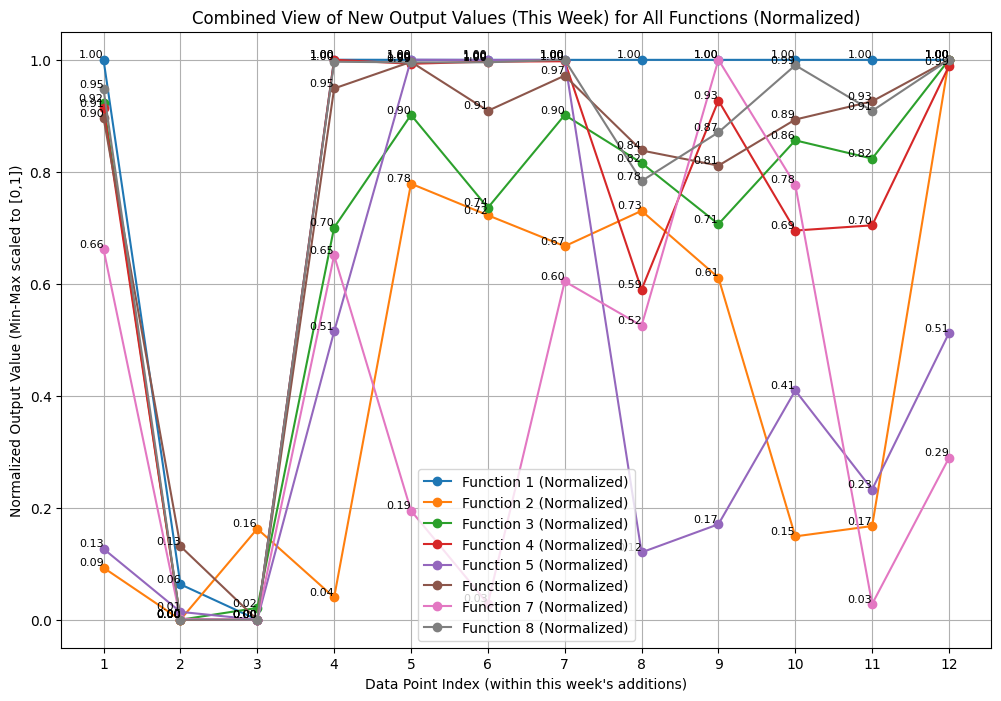

------------------------------
Note: This plot displays the sequence of newly observed *normalized* output values added for each function *this week*.
Normalization (Min-Max scaling to [0,1]) has been applied independently to each function's new output data for better visual comparison.
To visualize trends across multiple distinct 'weeks' (e.g., Week 1, Week 2 cumulative data), the notebook would need a mechanism to store and retrieve historical data from previous runs.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

print("\n--- Combined Visualization of Current Week's New Output Data (Normalized) ---")

plt.figure(figsize=(12, 8))
all_x_ticks = []

for function_idx, data in weekly_data_to_add.items():
    new_outputs = data['outputs']

    # Normalize the outputs using Min-Max scaling for each function
    min_output = new_outputs.min()
    max_output = new_outputs.max()
    # Avoid division by zero if all values are the same
    if max_output == min_output:
        normalized_outputs = np.zeros_like(new_outputs) # Or ones, depending on context
    else:
        normalized_outputs = (new_outputs - min_output) / (max_output - min_output)

    x_values = np.arange(len(normalized_outputs)) + 1
    plt.plot(x_values, normalized_outputs, marker='o', linestyle='-', label=f'Function {function_idx} (Normalized)')
    all_x_ticks.extend(x_values)

    # Add value at each data point
    for i, txt in enumerate(normalized_outputs):
        plt.text((i + 1), txt, f'{txt:.2f}', ha='right', va='bottom', fontsize=8)

plt.title('Combined View of New Output Values (This Week) for All Functions (Normalized)')
plt.xlabel('Data Point Index (within this week\'s additions)')
plt.ylabel('Normalized Output Value (Min-Max scaled to [0,1])')
plt.grid(True)
plt.xticks(sorted(list(set(all_x_ticks)))) # Ensure x-axis ticks are integers for each data point
plt.legend()
plt.show()

print("-" * 30)
# Add a note about historical context for clarification.
print("Note: This plot displays the sequence of newly observed *normalized* output values added for each function *this week*.")
print("Normalization (Min-Max scaling to [0,1]) has been applied independently to each function's new output data for better visual comparison.")
print("To visualize trends across multiple distinct 'weeks' (e.g., Week 1, Week 2 cumulative data), the notebook would need a mechanism to store and retrieve historical data from previous runs.")

### Modified Bayesian Optimization Loop

This cell now includes logic to append the new weekly blackbox data (defined in the `weekly_data_to_add` dictionary above) to the `initial_inputs` and `initial_outputs` for each function, making the historical data cumulative before the Gaussian Process model is fitted. This ensures the model learns from all available data up to the current week.

### Explanation of the Bayesian Optimization Code with Gaussian Process Surrogate

This code cell implements a classic **Bayesian Optimization** approach using a **Gaussian Process (GP)** as its surrogate model. The primary goal is to efficiently find optimal input parameters for several 'black-box' functions by intelligently exploring the search space, aiming to maximize their outputs with minimal evaluations.

Here's a detailed explanation of its components and workflow:

1.  **Imports and Setup**:
    *   `torch`, `botorch`, `gpytorch`, and `numpy` are imported. `botorch` and `gpytorch` are specifically designed for GP-based Bayesian Optimization in PyTorch.
    *   `torch.manual_seed(42)` ensures reproducibility of operations involving PyTorch.
    *   `function_hyperparameters` is a dictionary allowing for dynamic configuration of acquisition function choices (like Upper Confidence Bound - UCB, or Expected Improvement - EI) and their specific parameters (`beta_value` for UCB) on a per-function basis. Default values are provided if function-specific settings are not defined.

2.  **Function Iteration Loop**:
    *   The code iterates through functions 1 to 8, performing Bayesian Optimization for each.
    *   **Data Loading and Aggregation**: For each `function_idx`, it loads historical input-output data from `initial_inputs.npy` and `initial_outputs.npy`. Crucially, it then appends any *new* data points from the `weekly_data_to_add` dictionary for the current week. This makes the historical dataset cumulative, allowing the model to learn from all available observations over time.
    *   **Invalid Input Filtering**: New data points with input values exceeding `0.999999` are filtered out, with a warning message indicating how many points were ignored.
    *   **Dynamic Dimension and Bounds**: The dimensionality (`dim`) of the input space is determined from the data. The search bounds for the optimization, specified as `torch.tensor` objects, constrain inputs to the `[0.0, 0.999999]` range in each dimension.
    *   **Data Preparation**: NumPy arrays (`initial_inputs`, `initial_outputs`) are converted into PyTorch `double` tensors (`X`, `Y`) and reshaped (`Y.unsqueeze(-1)`) to meet the input requirements of `botorch` and `gpytorch`.

3.  **Adaptive Hyperparameter Heuristics**:
    *   This section implements a basic heuristic to dynamically adjust the `beta_value` (which controls the exploration-exploitation trade-off) of the UCB acquisition function.
    *   If the `current_max_output` is very low (e.g., negative, which might indicate a poor search region), `beta_value` is increased to encourage more exploration.
    *   If the standard deviation of `Y` is very small and there's enough data, suggesting the optimization might be converging or stuck in a local optimum, `beta_value` is also increased to encourage further exploration.

4.  **Gaussian Process (GP) Surrogate Model**:
    *   `model = SingleTaskGP(X, Y)`: A `SingleTaskGP` (Gaussian Process for single-objective optimization) is instantiated using the aggregated historical inputs (`X`) and outputs (`Y`). This model learns a probabilistic representation of the black-box function, providing both a mean prediction and an uncertainty estimate for any unseen input.
    *   `mll = ExactMarginalLogLikelihood(model.likelihood, model)`: The `ExactMarginalLogLikelihood` is set up. Maximizing this is a standard way to optimize the hyperparameters of a Gaussian Process model.
    *   `fit_gpytorch_mll(mll)`: The GP model's hyperparameters are optimized by maximizing the marginal log-likelihood, effectively fitting the model to the observed data.

5.  **Acquisition Function**: The acquisition function guides where to sample next by balancing exploration (sampling in uncertain regions to reduce uncertainty) and exploitation (sampling in promising regions to improve the current best).
    *   The `current_choice` (either "EI" for Expected Improvement or "UCB" for Upper Confidence Bound) is determined based on the `function_hyperparameters` or `DEFAULT_CHOICE`.
    *   **Expected Improvement (EI)**: If "EI" is chosen, `LogExpectedImprovement` is used. It quantifies how much improvement is expected over the current best observed output. It tends to be effective at quickly converging to an optimum.
    *   **Upper Confidence Bound (UCB)**: If "UCB" is chosen, `UpperConfidenceBound` is used. It selects points with a high predicted mean or high uncertainty (scaled by `beta`). The `current_beta_value` is influenced by the adaptive heuristics.

6.  **Optimizing the Acquisition Function**:
    *   `optimize_acqf` is called to find the input point (`new_x_candidate`) that maximizes the chosen acquisition function. This is a separate optimization problem within the Bayesian Optimization loop.
    *   `q=1` means it generates a single input recommendation.
    *   `num_restarts` and `raw_samples` parameters control the thoroughness of this optimization, helping to avoid local optima in the acquisition function itself.

7.  **Duplicate Handling and Perturbation**:
    *   After `new_x_candidate` is found, the code checks if this candidate is "too close" (within a `1e-6` Euclidean distance tolerance) to any existing historical input points (`X`).
    *   If it's a duplicate, the process retries (`max_optimization_retries` times) to find a unique point.
    *   As a last resort, if no unique point can be found after all retries, the last best candidate is slightly `perturbed` with a small amount of random noise (`perturbation_scale = 1e-4`). This ensures that a distinct, albeit slightly modified, input is always suggested to prevent stagnation.
    *   The `perturbed_vector` is then `clipped` to ensure it stays within the defined search `bounds`.

8.  **Next Action Item**: Finally, the script prints the `next_input_vector` for the current function. These are the recommended parameters for the user to evaluate in their external black-box function, continuing the iterative optimization process.

In [9]:
import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.acquisition import ExpectedImprovement, UpperConfidenceBound, LogExpectedImprovement
from botorch.optim import optimize_acqf
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)

# --- Dynamic Hyperparameters Configuration (per function) ---
# Define a dictionary to store hyperparameters for each function.
# If a function_idx is not present, default values will be used.
function_hyperparameters = {
    1: {'CHOICE': 'UCB', 'beta_value': 2.0},  # Example: UCB with lower beta for function 1
    2: {'CHOICE': 'UCB', 'beta_value': 2.0},
    3: {'CHOICE': 'UCB', 'beta_value': 2.0},
    4: {'CHOICE': 'UCB', 'beta_value': 2.0},
    5: {'CHOICE': 'UCB', 'beta_value': 2.0},
    6: {'CHOICE': 'UCB', 'beta_value': 2.0}
    # Add more functions as needed
    # 3: {'CHOICE': 'UCB', 'beta_value': 3.0},
    # 4: {'CHOICE': 'EI'},
}

# Default hyperparameters
DEFAULT_CHOICE = "UCB"
DEFAULT_BETA_VALUE = 2.0
# ------------------------------------------------------------


# Loop through functions 1 to 8
for function_idx in range(1, 9):
    print(f"\n--- Processing Function {function_idx} ---")

    # Read Values dynamically
    inputs_path = f'week1/function_{function_idx}/initial_inputs.npy'
    outputs_path = f'week1/function_{function_idx}/initial_outputs.npy'

    try:
        initial_inputs = np.load(inputs_path, mmap_mode='r')
        initial_outputs = np.load(outputs_path, mmap_mode='r')
    except FileNotFoundError:
        print(f"Skipping Function {function_idx}: Data files not found at {inputs_path} or {outputs_path}")
        continue # Skip to the next function if files are not found

    # --- Add this week's blackbox evaluation results ---
    if function_idx in weekly_data_to_add:
        function_data = weekly_data_to_add[function_idx]
        if not function_data.get('process', True): # Default to True if 'process' key is missing
            print(f"Skipping appending weekly data for Function {function_idx} as 'process' is False.")
        else:
            new_inputs = function_data['inputs']
            new_outputs = function_data['outputs']

            # Filter out invalid inputs (values > 0.999999)
            valid_indices = np.all(new_inputs <= 0.999999, axis=1)
            filtered_new_inputs = new_inputs[valid_indices]
            filtered_new_outputs = new_outputs[valid_indices]

            if len(new_inputs) > len(filtered_new_inputs):
                num_invalid = len(new_inputs) - len(filtered_new_inputs)
                print(f"Warning: {num_invalid} data points for Function {function_idx} were ignored due to invalid input values (> 0.999999).")

            if len(filtered_new_inputs) == 0:
                print(f"No valid new data to append for Function {function_idx}.")
            else:
                # Check for dimension compatibility before appending
                if initial_inputs.shape[1] != filtered_new_inputs.shape[1]:
                    print(f"Warning: Dimension mismatch for Function {function_idx}. Skipping appending valid new data.")
                else:
                    initial_inputs = np.append(initial_inputs, filtered_new_inputs, axis=0)
                    initial_outputs = np.append(initial_outputs, filtered_new_outputs)
                    print(f"Appended {len(filtered_new_inputs)} valid new weekly data points for Function {function_idx}.")
    # ---------------------------------------------------

    # Determine dimension dynamically
    dim = initial_inputs.shape[1]

    # 1. Configuration
    # Define bounds: 2 x D tensor (Lower bounds row, Upper bounds row)
    bounds = torch.tensor(
        [[0.0] * dim, [0.999999] * dim],
        dtype=torch.double
    )

    # 2. Historical Data
    X = torch.from_numpy(initial_inputs).double()
    Y = torch.from_numpy(initial_outputs).double().unsqueeze(-1) # Reshape to (n_samples, 1) for BoTorch

    print(f"X shape: {X.shape}")
    print(f"Y shape: {Y.shape}")
    print(f"Current best output value found so far: {Y.max().item():.6f}")

    # --- Simple Adaptive Hyperparameter Heuristic (based on cumulative results) ---
    # This is a basic example of how to make 'beta_value' adaptive based on the
    # observed results 'Y'. More sophisticated tuning would involve meta-learning
    # or a separate optimization loop for hyperparameters.

    # 3. Initialize and fit the Gaussian Process Surrogate Model
    model = SingleTaskGP(X, Y)
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)

    # 4. Define Acquisition Function for Maximization (Dynamically Chosen)
    func_config = function_hyperparameters.get(function_idx, {})
    current_choice = func_config.get('CHOICE', DEFAULT_CHOICE)

    if current_choice == "UCB":
        explicitly_set_beta = func_config.get('beta_value')

        if explicitly_set_beta is not None:
            # If beta_value is explicitly set in function_hyperparameters, use it directly.
            current_beta_value = explicitly_set_beta
            print(f"Using Acquisition Function: {current_choice} (Beta: {current_beta_value:.2f} - explicitly set)")
        else:
            # If beta_value is not explicitly set, apply heuristics to the default beta_value.
            suggested_beta_value = DEFAULT_BETA_VALUE # Start heuristics from default
            if Y.numel() > 0: # Ensure there's data to analyze
                current_max_output = Y.max().item()

                if current_max_output < 0.0: # Example threshold for potentially negative functions
                    suggested_beta_value = max(suggested_beta_value, 3.5) # Increase beta for more exploration
                    print(f"  Heuristic: Low max output ({current_max_output:.2f}), increasing beta to {suggested_beta_value:.2f} for more exploration.")

                if Y.std().item() < 0.01 and Y.numel() > 5: # Small std and enough data points
                    suggested_beta_value = max(suggested_beta_value, 3.0) # Ensure some exploration
                    print(f"  Heuristic: Small std dev ({Y.std().item():.4f}), increasing beta to {suggested_beta_value:.2f} to escape potential local optima.")

            current_beta_value = suggested_beta_value
            print(f"Using Acquisition Function: {current_choice} (Beta: {current_beta_value:.2f} - adaptive)")
    else: # For EI or other acquisition functions, beta is not relevant
        current_beta_value = DEFAULT_BETA_VALUE # This value won't be used by EI, but setting it for completeness
        print(f"Using Acquisition Function: {current_choice}")


    if current_choice == "EI":
        best_f = Y.max()
        acq_func = LogExpectedImprovement(model=model, best_f=best_f, maximize=True)
    elif current_choice == "UCB":
        acq_func = UpperConfidenceBound(model=model, beta=current_beta_value, maximize=True)

    # 5. Optimize Acquisition Function to find the Single Next Input
    max_optimization_retries = 10
    found_unique_point = False
    next_input_vector = None

    for _ in range(max_optimization_retries):
        new_x_candidate, new_acq_value = optimize_acqf(
            acq_function=acq_func,
            bounds=bounds,
            q=1,                   # Generate a single input recommendation
            num_restarts=10,       # Increased restarts for better acquisition function optimization
            raw_samples=50         # Increased raw samples for better initialization of restarts
        )

        candidate_np = new_x_candidate.detach().numpy().flatten()

        # Check if the candidate is "too close" to any existing points in X
        is_duplicate = False
        if X.numel() > 0:
            # Calculate Euclidean distance from candidate to all existing points
            distances = torch.cdist(new_x_candidate, X, p=2)
            min_distance = distances.min().item()

            # Define a small tolerance for floating point comparison
            # A value like 1e-6 is generally suitable for distinguishing points in [0,1] space
            if min_distance < 1e-6:
                is_duplicate = True
                # print(f"  Warning: Suggested point {candidate_np} (min dist to X: {min_distance:.8f}) is too close to an existing point. Retrying optimization...")

        if not is_duplicate:
            next_input_vector = candidate_np
            found_unique_point = True
            break

    if not found_unique_point:
        print(f"  Critical Warning: Failed to find a unique input after {max_optimization_retries} retries for Function {function_idx}. Suggesting a perturbed version of the best candidate.")
        # As a last resort, take the last candidate and perturb it randomly
        # Ensure new_x_candidate is defined from the last loop iteration
        if 'new_x_candidate' not in locals(): # In case loop never ran or failed before assignment
            new_x_candidate, _ = optimize_acqf(
                acq_function=acq_func, bounds=bounds, q=1, num_restarts=10, raw_samples=50
            )

        next_input_vector = new_x_candidate.detach().numpy().flatten()

        perturbation_scale = 1e-4 # Small perturbation
        random_noise = np.random.uniform(-perturbation_scale, perturbation_scale, size=dim) # Uniform noise for diversity
        perturbed_vector = next_input_vector + random_noise

        # Clip to bounds
        min_bound = bounds[0].cpu().numpy()
        max_bound = bounds[1].cpu().numpy()
        next_input_vector = np.clip(perturbed_vector, min_bound, max_bound)
        print(f"  Forcing perturbation to: {'-'.join([f'{x:.6f}' for x in next_input_vector])}")


    print("\n--- Next Weekly Action Item ---")
    print(f"For Function {function_idx}, run your external black-box function using these parameters:")
    print(f"  Next input: {'-'.join([f'{x:.6f}' for x in next_input_vector])}")


--- Processing Function 1 ---
Appended 12 valid new weekly data points for Function 1.
X shape: torch.Size([22, 2])
Y shape: torch.Size([22, 1])
Current best output value found so far: 0.000002
Using Acquisition Function: UCB (Beta: 2.00 - explicitly set)

--- Next Weekly Action Item ---
For Function 1, run your external black-box function using these parameters:
  Next input: 0.316764-0.530809

--- Processing Function 2 ---
Appended 12 valid new weekly data points for Function 2.
X shape: torch.Size([22, 2])
Y shape: torch.Size([22, 1])
Current best output value found so far: 0.795902
Using Acquisition Function: UCB (Beta: 2.00 - explicitly set)

--- Next Weekly Action Item ---
For Function 2, run your external black-box function using these parameters:
  Next input: 0.690855-0.478940

--- Processing Function 3 ---
Appended 11 valid new weekly data points for Function 3.
X shape: torch.Size([26, 3])
Y shape: torch.Size([26, 1])
Current best output value found so far: -0.004630
Using 

## Resources

### Explanation of the Bayesian Optimization Code with Neural Network Surrogate

This code cell implements a Bayesian Optimization process, but instead of the traditional Gaussian Process, it uses a custom feed-forward Neural Network as the surrogate model. It iterates through 8 different 'black-box' functions, aiming to find the next best input parameters for each. Here's a breakdown of how it works:

**1. Neural Network Definition (`NeuralNetworkSurrogate` class):**
   - This defines a simple neural network with two hidden layers using ReLU activation functions and an output layer that produces a single scalar value. It's designed to learn the mapping from input parameters (features) to the output (performance of the black-box function).

**2. Neural Network Training Function (`train_nn_surrogate`):**
   - This helper function takes the neural network model, training inputs (`X_train`), and outputs (`Y_train`).
   - It uses the Adam optimizer and Mean Squared Error (MSE) loss to train the network for a specified number of epochs (100 in this case). The goal is for the neural network to accurately predict the black-box function's output given new inputs.

**3. Main Optimization Loop (for `function_idx` 1 to 8):**
   - **Data Loading and Aggregation:** For each function, it loads historical `initial_inputs.npy` and `initial_outputs.npy`. It then appends any new data for the current week from the `weekly_data_to_add` dictionary. This step is crucial for the model to continuously learn from new observations.
   - **Invalid Input Filtering:** It includes logic to filter out any new data points where input values exceed `0.999999`, printing a warning if such points are found.
   - **Dynamic Dimension and Bounds:** It determines the dimensionality (`dim`) of the input space dynamically and sets the optimization bounds for each dimension from `0.0` to `0.999999`.
   - **Data Preparation for PyTorch:** The NumPy arrays of inputs (`X`) and outputs (`Y`) are converted into PyTorch tensors and reshaped appropriately for the neural network.
   - **Neural Network Training:** The `NeuralNetworkSurrogate` is initialized for the current function's input dimension and then trained using the aggregated historical data (`X`, `Y`).
   - **Acquisition Strategy (Next Input Suggestion):**
     - Since a standard neural network doesn't directly provide uncertainty estimates like Gaussian Processes, the acquisition strategy is simplified. It generates a `num_candidates` (200) random input points within the defined bounds.
     - It then uses the trained neural network to predict the output for each of these candidate points.
     - The candidate that yields the highest predicted output is selected as the `new_x_candidate`.
   - **Duplicate Point Handling:** To encourage exploration and avoid repeatedly suggesting already evaluated points, it checks if the `new_x_candidate` is too close to any existing historical input points (`X`). If it is a duplicate, it retries generating new candidates.
   - **Perturbation as Fallback:** If after `max_optimization_retries` (10 retries), a unique point cannot be found, it takes the last best candidate and adds a small random perturbation to it. This ensures a new, albeit slightly modified, input is always suggested.
   - **Output:** Finally, it prints the suggested `next_input_vector` for the current function, which represents the parameters recommended for the next black-box evaluation.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)

# --- Define the Neural Network Surrogate Model ---
class NeuralNetworkSurrogate(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super(NeuralNetworkSurrogate, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dim, 1) # Output a single scalar value

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# Function to train the neural network
def train_nn_surrogate(model, X_train, Y_train, num_epochs=100, learning_rate=0.01):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss() # Mean Squared Error Loss

    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        optimizer.zero_grad() # Zero the gradients
        outputs = model(X_train)
        loss = criterion(outputs, Y_train)
        loss.backward() # Backpropagation
        optimizer.step() # Update weights
    print(f"Neural Network trained for {num_epochs} epochs. Final Loss: {loss.item():.4f}")


# Loop through functions 1 to 8
for function_idx in range(1, 9):
    print(f"\n--- Processing Function {function_idx} ---")

    # Read Values dynamically
    inputs_path = f'week1/function_{function_idx}/initial_inputs.npy'
    outputs_path = f'week1/function_{function_idx}/initial_outputs.npy'

    try:
        initial_inputs = np.load(inputs_path, mmap_mode='r')
        initial_outputs = np.load(outputs_path, mmap_mode='r')
    except FileNotFoundError:
        print(f"Skipping Function {function_idx}: Data files not found at {inputs_path} or {outputs_path}")
        continue # Skip to the next function if files are not found

    # --- Add this week's blackbox evaluation results ---
    if function_idx in weekly_data_to_add:
        function_data = weekly_data_to_add[function_idx]
        if not function_data.get('process', True): # Default to True if 'process' key is missing
            print(f"Skipping appending weekly data for Function {function_idx} as 'process' is False.")
        else:
            new_inputs = function_data['inputs']
            new_outputs = function_data['outputs']

            # Filter out invalid inputs (values > 0.999999)
            valid_indices = np.all(new_inputs <= 0.999999, axis=1)
            filtered_new_inputs = new_inputs[valid_indices]
            filtered_new_outputs = new_outputs[valid_indices]

            if len(new_inputs) > len(filtered_new_inputs):
                num_invalid = len(new_inputs) - len(filtered_new_inputs)
                print(f"Warning: {num_invalid} data points for Function {function_idx} were ignored due to invalid input values (> 0.999999).")

            if len(filtered_new_inputs) == 0:
                print(f"No valid new data to append for Function {function_idx}.")
            else:
                # Check for dimension compatibility before appending
                if initial_inputs.shape[1] != filtered_new_inputs.shape[1]:
                    print(f"Warning: Dimension mismatch for Function {function_idx}. Skipping appending valid new data.")
                else:
                    initial_inputs = np.append(initial_inputs, filtered_new_inputs, axis=0)
                    initial_outputs = np.append(initial_outputs, filtered_new_outputs)
                    print(f"Appended {len(filtered_new_inputs)} valid new weekly data points for Function {function_idx}.")
    # ---------------------------------------------------

    # Determine dimension dynamically
    dim = initial_inputs.shape[1]

    # 1. Configuration
    # Define bounds: 2 x D tensor (Lower bounds row, Upper bounds row)
    bounds = torch.tensor(
        [[0.0] * dim, [0.999999] * dim],
        dtype=torch.double
    )

    # 2. Historical Data
    X = torch.from_numpy(initial_inputs).double()
    Y = torch.from_numpy(initial_outputs).double().unsqueeze(-1) # Reshape to (n_samples, 1)

    print(f"X shape: {X.shape}")
    print(f"Y shape: {Y.shape}")
    print(f"Current best output value found so far: {Y.max().item():.6f}")

    # 3. Initialize and train the Neural Network Surrogate Model
    nn_model = NeuralNetworkSurrogate(input_dim=dim).double() # Ensure double precision
    train_nn_surrogate(nn_model, X, Y)

    # 4. Define Acquisition Strategy for Maximization (using NN predictions)
    # Generate random candidates, predict their values, and select the best.
    # A perturbation step can be added for exploration if a unique point isn't found.

    # 5. Optimize Acquisition Function to find the Single Next Input
    max_optimization_retries = 10
    found_unique_point = False
    next_input_vector = None

    num_candidates = 200 # Number of random candidates to sample for optimization
    new_x_candidate = None # Initialize to None

    for _ in range(max_optimization_retries):
        # Generate random candidates within the bounds
        candidate_set = bounds[0] + (bounds[1] - bounds[0]) * torch.rand(num_candidates, dim, dtype=torch.double)

        nn_model.eval() # Set model to evaluation mode
        with torch.no_grad(): # Disable gradient calculations
            predictions = nn_model(candidate_set)

        # Select the candidate with the highest predicted value
        best_candidate_idx = torch.argmax(predictions)
        new_x_candidate = candidate_set[best_candidate_idx].unsqueeze(0) # Keep as 1xdim tensor

        candidate_np = new_x_candidate.detach().numpy().flatten()

        # Check if the candidate is "too close" to any existing points in X
        is_duplicate = False
        if X.numel() > 0:
            distances = torch.cdist(new_x_candidate, X, p=2)
            min_distance = distances.min().item()
            if min_distance < 1e-6:
                is_duplicate = True

        if not is_duplicate:
            next_input_vector = candidate_np
            found_unique_point = True
            break

    if not found_unique_point:
        print(f"  Critical Warning: Failed to find a unique input after {max_optimization_retries} retries for Function {function_idx}. Suggesting a perturbed version of the best candidate.")
        # If no unique point found after retries, or new_x_candidate was never set,
        # generate a random candidate to perturb as a last resort.
        if new_x_candidate is None:
            new_x_candidate = bounds[0] + (bounds[1] - bounds[0]) * torch.rand(1, dim, dtype=torch.double)

        next_input_vector = new_x_candidate.detach().numpy().flatten()

        perturbation_scale = 1e-4 # Small perturbation
        random_noise = np.random.uniform(-perturbation_scale, perturbation_scale, size=dim) # Uniform noise for diversity
        perturbed_vector = next_input_vector + random_noise

        # Clip to bounds
        min_bound = bounds[0].cpu().numpy()
        max_bound = bounds[1].cpu().numpy()
        next_input_vector = np.clip(perturbed_vector, min_bound, max_bound)
        print(f"  Forcing perturbation to: {'-'.join([f'{x:.6f}' for x in next_input_vector])}")


    print("\n--- Next Weekly Action Item ---")
    print(f"For Function {function_idx}, run your external black-box function using these parameters:")
    print(f"  Next input: {'-'.join([f'{x:.6f}' for x in next_input_vector])}")


--- Processing Function 1 ---
Appended 12 valid new weekly data points for Function 1.
X shape: torch.Size([22, 2])
Y shape: torch.Size([22, 1])
Current best output value found so far: 0.000002
Neural Network trained for 100 epochs. Final Loss: 0.0000

--- Next Weekly Action Item ---
For Function 1, run your external black-box function using these parameters:
  Next input: 0.284004-0.568436

--- Processing Function 2 ---
Appended 12 valid new weekly data points for Function 2.
X shape: torch.Size([22, 2])
Y shape: torch.Size([22, 1])
Current best output value found so far: 0.795902
Neural Network trained for 100 epochs. Final Loss: 0.0107

--- Next Weekly Action Item ---
For Function 2, run your external black-box function using these parameters:
  Next input: 0.681690-0.410524

--- Processing Function 3 ---
Appended 11 valid new weekly data points for Function 3.
X shape: torch.Size([26, 3])
Y shape: torch.Size([26, 1])
Current best output value found so far: -0.004630
Neural Network

### Explanation of the Bayesian Optimization Code with Logistic Regression Surrogate

This code cell implements a modified Bayesian Optimization process, where instead of using a traditional Gaussian Process or a Neural Network, it employs a **Logistic Regression** model as the surrogate. The key innovation here is the transformation of the continuous optimization problem into a binary classification task. The script iterates through 8 different 'black-box' functions, aiming to suggest the next best input parameters for each.

Here's a breakdown of how it works:

1.  **Imports and Setup:**
    *   `numpy` is imported for numerical operations.
    *   `LogisticRegression` from `sklearn.linear_model` is the core surrogate model.
    *   `warnings` are used to suppress potential convergence warnings from `sklearn`, making the output cleaner for this example.
    *   A `numpy` random seed (`np.random.seed(42)`) is set for reproducibility, ensuring consistent results across runs.

2.  **Function Iteration Loop:**
    *   The code processes each function from 1 to 8 in a loop.
    *   **Data Loading and Aggregation:** For each function, it loads historical `initial_inputs.npy` and `initial_outputs.npy`. These represent the accumulated knowledge about the function's behavior. Any new data points for the current week (from the `weekly_data_to_add` dictionary) are then appended to this historical dataset. This ensures the model continuously learns from all available observations.
    *   **Invalid Input Filtering:** Before appending, new data points are checked for validity (e.g., input values must be within the `[0, 0.999999]` range). Invalid points are ignored with a warning.
    *   **Dynamic Dimension and Bounds:** The dimensionality (`dim`) of the input space is determined based on the loaded data. The search `bounds_np` for optimizing the acquisition function are set from `0.0` to `0.999999` for each dimension.

3.  **Transformation to Classification Problem:**
    *   **Binarization of Outputs (`y_binary`):** This is the most critical step for using Logistic Regression. The continuous output values (`Y_np`) are converted into a binary target. A simple heuristic is used: the `median_Y` of all observed outputs is calculated. Output values *greater than* the median are assigned to class `1` (representing a 'good' or 'desirable' outcome), and values *less than or equal to* the median are assigned to class `0` (a 'bad' outcome).
    *   This effectively transforms the maximization problem (finding inputs that lead to high continuous outputs) into a binary classification problem (finding inputs that are likely to produce an output in the 'good' class).

4.  **Logistic Regression Model Training:**
    *   A `LogisticRegression` model is initialized. `solver='liblinear'` is a robust choice for smaller datasets, and `C=0.1` adds a small amount of L2 regularization to prevent overfitting. `random_state=42` ensures reproducibility of the model training.
    *   The model is trained (`lr_model.fit`) using the historical inputs (`X_np`) and their corresponding binarized outcomes (`y_binary`).
    *   A check is included to ensure that both classes (0 and 1) are present in `y_binary` to prevent training errors.

5.  **Acquisition Strategy for Next Input Suggestion:**
    *   **Candidate Generation:** The script generates `num_candidates` (e.g., 200) random input points uniformly distributed within the defined `bounds_np`.
    *   **Probability Prediction:** The trained `lr_model` then predicts the probability of each candidate belonging to class `1` (i.e., the probability of achieving a 'good' outcome) using `lr_model.predict_proba`. Since we aim to maximize, we are interested in maximizing this probability.
    *   **Selection:** The candidate input that has the highest predicted probability of being in class `1` is selected as `new_x_candidate_np`.

6.  **Duplicate Handling and Perturbation:**
    *   To promote exploration and prevent the algorithm from repeatedly suggesting points already evaluated, it checks if the `new_x_candidate_np` is too close to any already evaluated historical points. If it's a duplicate, it retries finding a unique point up to `max_optimization_retries` times. As a last resort, if a unique point cannot be found, it takes the best candidate and adds a small random `perturbation` to it. This ensures a new, albeit slightly modified, input is always suggested.
    *   **Output:** Finally, it prints the suggested `next_input_vector` for the current function, which represents the parameters recommended for the next black-box evaluation.

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression # New import
import warnings # To suppress potential sklearn convergence warnings

# Set random seed for reproducibility
np.random.seed(42) # Using numpy's random seed for consistency with sklearn

# Loop through functions 1 to 8
for function_idx in range(1, 9):
    print(f"\n--- Processing Function {function_idx} ---")

    # Read Values dynamically
    inputs_path = f'week1/function_{function_idx}/initial_inputs.npy'
    outputs_path = f'week1/function_{function_idx}/initial_outputs.npy'

    try:
        initial_inputs = np.load(inputs_path, mmap_mode='r')
        initial_outputs = np.load(outputs_path, mmap_mode='r')
    except FileNotFoundError:
        print(f"Skipping Function {function_idx}: Data files not found at {inputs_path} or {outputs_path}")
        continue # Skip to the next function if files are not found

    # --- Add this week's blackbox evaluation results ---
    if function_idx in weekly_data_to_add:
        function_data = weekly_data_to_add[function_idx]
        if not function_data.get('process', True): # Default to True if 'process' key is missing
            print(f"Skipping appending weekly data for Function {function_idx} as 'process' is False.")
        else:
            new_inputs = function_data['inputs']
            new_outputs = function_data['outputs']

            # Filter out invalid inputs (values > 0.999999)
            valid_indices = np.all(new_inputs <= 0.999999, axis=1)
            filtered_new_inputs = new_inputs[valid_indices]
            filtered_new_outputs = new_outputs[valid_indices]

            if len(new_inputs) > len(filtered_new_inputs):
                num_invalid = len(new_inputs) - len(filtered_new_inputs)
                print(f"Warning: {num_invalid} data points for Function {function_idx} were ignored due to invalid input values (> 0.999999).")

            if len(filtered_new_inputs) == 0:
                print(f"No valid new data to append for Function {function_idx}.")
            else:
                # Check for dimension compatibility before appending
                if initial_inputs.shape[1] != filtered_new_inputs.shape[1]:
                    print(f"Warning: Dimension mismatch for Function {function_idx}. Skipping appending valid new data.")
                else:
                    initial_inputs = np.append(initial_inputs, filtered_new_inputs, axis=0)
                    initial_outputs = np.append(initial_outputs, filtered_new_outputs)
                    print(f"Appended {len(filtered_new_inputs)} valid new weekly data points for Function {function_idx}.")
    # ---------------------------------------------------

    # Determine dimension dynamically
    dim = initial_inputs.shape[1]

    # 1. Configuration
    # Define bounds: 2 x D numpy array (Lower bounds row, Upper bounds row)
    bounds_np = np.array(
        [[0.0] * dim, [0.999999] * dim]
    )

    # 2. Historical Data
    X_np = initial_inputs
    Y_np = initial_outputs

    print(f"X shape: {X_np.shape}")
    print(f"Y shape: {Y_np.shape}")
    print(f"Current best output value found so far: {Y_np.max():.6f}")

    # --- Convert to classification problem for Logistic Regression ---
    if Y_np.shape[0] < 2: # Need at least two data points to define a median/threshold
        print(f"  Skipping optimization for Function {function_idx}: Not enough data points to train Logistic Regression.")
        continue

    # Define a threshold to binarize outputs for Logistic Regression
    # A common approach for optimization is to classify 'good' vs 'bad' outcomes
    # Here, we use the median as a simple threshold. Outputs > median are 'good' (class 1).
    median_Y = np.median(Y_np)
    y_binary = (Y_np > median_Y).astype(int)
    print(f"  Binarized Y (outputs > {median_Y:.4f} are class 1). Class 1 count: {np.sum(y_binary)}, Class 0 count: {len(y_binary) - np.sum(y_binary)}")

    # 3. Initialize and train the Logistic Regression Model
    # Suppress warnings about convergence for simplicity in this example
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # solver='liblinear' is generally good for small datasets and L1/L2 regularization.
        # C is the inverse of regularization strength; smaller values specify stronger regularization.
        lr_model = LogisticRegression(solver='liblinear', random_state=42, C=0.1)

        # Ensure there's at least one sample in each class for training
        if len(np.unique(y_binary)) < 2: # Check if both classes are present
            print(f"  Skipping optimization for Function {function_idx}: Only one class present in binarized outputs. Cannot train Logistic Regression.")
            continue

        lr_model.fit(X_np, y_binary)
        print(f"  Logistic Regression Model trained. Score (accuracy): {lr_model.score(X_np, y_binary):.4f}")

    # 4. Define Acquisition Strategy for Maximization (using LR probabilities)
    # We want to maximize the probability of belonging to class 1 ('good' outcomes)

    # 5. Optimize Acquisition Function to find the Single Next Input
    max_optimization_retries = 10
    found_unique_point = False
    next_input_vector = None

    num_candidates = 200 # Number of random candidates to sample for optimization
    new_x_candidate_np = None # Initialize to None for numpy array

    for _ in range(max_optimization_retries):
        # Generate random candidates within the bounds
        candidate_set_np = bounds_np[0] + (bounds_np[1] - bounds_np[0]) * np.random.rand(num_candidates, dim)

        # Predict the probability of class 1 ('good' outcome)
        if len(lr_model.classes_) == 2:
            # Assumes class 1 is the 'positive' class, need to find its index
            positive_class_idx = np.where(lr_model.classes_ == 1)[0][0]
            probabilities = lr_model.predict_proba(candidate_set_np)[:, positive_class_idx].flatten()
        else: # Fallback if for some reason only one class is detected (should be caught earlier)
            probabilities = np.zeros(num_candidates) # Default to 0 probability for safety


        # Select the candidate with the highest predicted probability
        best_candidate_idx = np.argmax(probabilities)
        new_x_candidate_np = candidate_set_np[best_candidate_idx].reshape(1, -1) # Keep as 1xdim array

        candidate_np = new_x_candidate_np.flatten()

        # Check if the candidate is "too close" to any existing points in X
        is_duplicate = False
        if X_np.shape[0] > 0:
            distances = np.linalg.norm(new_x_candidate_np - X_np, axis=1) # Euclidean distance
            min_distance = distances.min()
            if min_distance < 1e-6:
                is_duplicate = True

        if not is_duplicate:
            next_input_vector = candidate_np
            found_unique_point = True
            break

    if not found_unique_point:
        print(f"  Critical Warning: Failed to find a unique input after {max_optimization_retries} retries for Function {function_idx}. Suggesting a perturbed version of the best candidate.")

        # If no unique point found after retries, or new_x_candidate_np was never set,
        # generate a random candidate to perturb as a last resort.
        if new_x_candidate_np is None:
            new_x_candidate_np = bounds_np[0] + (bounds_np[1] - bounds_np[0]) * np.random.rand(1, dim)

        next_input_vector = new_x_candidate_np.flatten()

        perturbation_scale = 1e-4 # Small perturbation
        random_noise = np.random.uniform(-perturbation_scale, perturbation_scale, size=dim) # Uniform noise for diversity
        perturbed_vector = next_input_vector + random_noise

        # Clip to bounds
        next_input_vector = np.clip(perturbed_vector, bounds_np[0], bounds_np[1])
        print(f"  Forcing perturbation to: {'-'.join([f'{x:.6f}' for x in next_input_vector])}")


    print("\n--- Next Weekly Action Item ---")
    print(f"For Function {function_idx}, run your external black-box function using these parameters:")
    print(f"  Next input: {'-'.join([f'{x:.6f}' for x in next_input_vector])}")


--- Processing Function 1 ---
Appended 11 valid new weekly data points for Function 1.
X shape: (21, 2)
Y shape: (21,)
Current best output value found so far: 0.000002
  Binarized Y (outputs > 0.0000 are class 1). Class 1 count: 10, Class 0 count: 11
  Logistic Regression Model trained. Score (accuracy): 0.5238

--- Next Weekly Action Item ---
For Function 1, run your external black-box function using these parameters:
  Next input: 0.012154-0.969878

--- Processing Function 2 ---
Appended 11 valid new weekly data points for Function 2.
X shape: (21, 2)
Y shape: (21,)
Current best output value found so far: 0.611205
  Binarized Y (outputs > 0.2150 are class 1). Class 1 count: 10, Class 0 count: 11
  Logistic Regression Model trained. Score (accuracy): 0.3810

--- Next Weekly Action Item ---
For Function 2, run your external black-box function using these parameters:
  Next input: 0.994907-0.173895

--- Processing Function 3 ---
Appended 10 valid new weekly data points for Function 3.
